In [233]:
! pip install pandas numpy scikit-learn scipy matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 20.2 MB/s eta 0:00:000:00:01m eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 KB 52.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.2 MB/s eta 0:00:00m eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 63.5 MB/s eta 0:00:00m eta 0:00:010:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.9 MB/s eta 0:00:003 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 KB 80.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [229]:
import os

In [163]:

def load_epagri_csvs(folder_path, drop_all_nan_cols=True):
    results = []
    
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            file_path = os.path.join(folder_path, file)
            
            # Metadata (first line)
            with open(file_path, "r", encoding="utf-8") as f:
                meta = f.readline().strip()
            
            # Read data (explicit header handling)
            df = pd.read_csv(
                file_path,
                skiprows=1,
                header=0,  # explicitly say second line is header
                encoding="cp1252",
                parse_dates=["Data Horario"],
                date_format="%d/%m/%Y %H:%M:%S",
                na_values=["9999.9", "9999", ""],
                engine="python"  # more tolerant of malformed CSV
            )
            
            # Drop extra unnamed column from trailing comma
            df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
            
            # Ensure Codigo is not treated as index accidentally
            if df.index.name == "Codigo":
                df = df.reset_index()
            
            # Optional cleanup
            if drop_all_nan_cols:
                df = df.dropna(axis=1, how="all")
            
            results.append((meta, df))
    
    return results

In [239]:
def test_missingness_randomness(df, col, features=None):
    """
    Tests whether missingness in `col` appears random (MCAR-like) or depends on other variables (MAR-like).
    """
    
    df = df.copy()
    
    # 1. Missingness indicator
    df["_missing"] = df[col].isna().astype(int)
    
    print(f"\n=== Missingness analysis for: {col} ===")
    print(f"Missing rate: {df['_missing'].mean():.2%}")
    
    # If no missing data, stop
    if df["_missing"].sum() == 0:
        print("No missing values found.")
        return
    
    # Default features = all numeric except target and indicator
    if features is None:
        features = df.select_dtypes(include=np.number).columns.tolist()
        features = [f for f in features if f not in [col, "_missing"]]
    
    # Drop rows where features are missing
    data = df[features + ["_missing"]].dropna()
    
    # 2. Logistic regression test (predict missingness)
    if len(data) > 10 and len(features) > 0:
        X = data[features]
        y = data["_missing"]
        
        model = LogisticRegression(max_iter=1000)
        model.fit(X, y)
        
        preds = model.predict_proba(X)[:, 1]
        auc = roc_auc_score(y, preds)
        
        print(f"\nLogistic model AUC for missingness prediction: {auc:.3f}")
        
        if auc > 0.75:
            print("→ Strong evidence missingness depends on other variables (likely MAR)")
        elif auc > 0.6:
            print("→ Some evidence missingness is not random")
        else:
            print("→ Weak evidence of structure (closer to MCAR)")
    
    # 3. Chi-square tests for categorical-like signals (binned numerics)
    print("\nChi-square tests (binned relationships):")
    
    for f in features[:5]:  # limit for readability
        try:
            binned = pd.qcut(df[f], q=5, duplicates="drop")
            table = pd.crosstab(binned, df["_missing"])
            chi2, p, _, _ = chi2_contingency(table)
            
            print(f"{f}: p-value = {p:.4f}")
        except Exception:
            pass

In [164]:
dfs=load_epagri_csvs("dados_EPAGRI", True)

# Data Cleaning

## Checking missing values

In [175]:
for n,e in enumerate(dfs):
    print(n,e[0])

0 1053,Major Gercino - Campinho,Major Gercino,-27.48,-49.12,777,
1 1006,Florian�polis - Cetre/Epagri,Florian�polis,-27.58,-48.51,10,
2 2384,Santo Amaro da Imperatriz - Bairro Sul do Rio,Santo Amaro da Imperatriz,-27.7,-48.74,11,
3 1070,Imbituba - Porto de Imbituba - Anem�metro,Imbituba,-28.23,-48.65,3,
4 2385,Tijucas - Bairro Universit�rios,Tijucas,-27.24,-48.67,31,
5 2397,Florian�polis - Santo Ant�nio de Lisboa,Florian�polis,-27.53,-48.51,58,
6 2951,Florianopolis (Sul da Ilha),Florian�polis,-27.82,-48.56,0,
7 1073,Lagoa do Peri CASAN,Florian�polis,-27.73,-48.51,5,
8 1054,S�o Bonif�cio - Est. Geral do Rio Atafona I,S�o Bonif�cio,-27.91,-48.92,602,
9 2432,Cambori� - Salto dos Pil�es,Cambori�,-27.09,-48.76,35,
10 2424,Florian�polis - Carij�s,Florian�polis,-27.47,-48.49,5,
11 2469,Florian�polis - Lagoa do Peri - CASAN,Florian�polis,-27.73,-48.51,3,
12 2498,Imaru� - Apicultura - Colmeia 2,Imaru�,-28.19,-48.77,6,
13 1050,Rancho Queimado - Vin�cola Terramilia,Rancho Queimado,-27.7,-49.06,967

In [176]:
n = 1
print(dfs[n][0])
dfs[n][1]


1006,Florian�polis - Cetre/Epagri,Florian�polis,-27.58,-48.51,10,


,Codigo,Data Horario,TempArInst(C),TempMin(C),TempMax(C),Vel.MediaVento(m/s),Dir.MediaVento(Graus),VentoMax(m/s),PressaoAtm(mB),UmidRelMedia(%),Precipitacao(mm)
0,1006,2024-05-01 00:00:00,21.03,20.91,21.21,0.24,120.70,1.37,NaN,96.3,0.0
1,1006,2024-05-01 01:00:00,21.30,21.01,21.58,0.55,168.10,2.06,NaN,97.2,0.0
2,1006,2024-05-01 02:00:00,21.18,21.04,21.32,0.64,71.84,1.47,NaN,97.2,0.0
3,1006,2024-05-01 03:00:00,20.86,20.83,21.23,0.24,84.80,0.98,NaN,97.4,0.0
4,1006,2024-05-01 04:00:00,20.90,20.75,21.04,0.35,39.84,1.27,NaN,97.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...
16795,1006,2026-03-31 19:00:00,23.54,23.54,25.02,1.07,152.70,4.38,1011.23,81.3,0.0
16796,1006,2026-03-31 20:00:00,22.58,22.56,23.58,0.56,50.25,1.96,1011.84,85.9,0.0
16797,1006,2026-03-31 21:00:00,21.70,21.59,22.61,0.40,63.56,1.50,1012.23,89.7,0.0
16798,1006,2026-03-31 22:00:00,21.40,21.35,21.85,0.59,86.50,1.60,1012.48,92.4,0.0


In [177]:
dfs[n][1].describe()

,Codigo,Data Horario,TempArInst(C),TempMin(C),TempMax(C),Vel.MediaVento(m/s),Dir.MediaVento(Graus),VentoMax(m/s),PressaoAtm(mB),UmidRelMedia(%),Precipitacao(mm)
count,16800.0,16800,16777.000000,16775.000000,16775.000000,16786.000000,16786.000000,16786.000000,12274.000000,16512.000000,16778.000000
mean,1006.0,2025-04-15 23:30:00,21.128852,20.718408,21.553969,1.392381,148.211003,4.295818,1014.703157,85.436509,0.222994
min,1006.0,2024-05-01 00:00:00,3.270000,2.940000,3.600000,0.000000,0.000000,0.000000,990.010000,32.960000,0.000000
25%,1006.0,2024-10-22 23:45:00,18.200000,17.810000,18.600000,0.580000,66.652500,2.110000,1010.960000,77.907500,0.000000
50%,1006.0,2025-04-15 23:30:00,21.300000,20.960000,21.680000,1.270000,138.900000,4.120000,1014.270000,87.900000,0.000000
75%,1006.0,2025-10-07 23:15:00,24.330000,23.910000,24.750000,2.030000,194.300000,6.080000,1018.030000,94.700000,0.000000
max,1006.0,2026-03-31 23:00:00,37.410000,35.860000,37.460000,5.520000,360.000000,17.690000,1032.220000,100.000000,60.000000
std,0.0,NaN,4.628080,4.598040,4.657317,0.930908,103.876955,2.460317,5.680203,11.031881,1.340722


In [178]:
dfs[n][1].isna().sum()

Codigo                      0
Data Horario                0
TempArInst(C)              23
TempMin(C)                 25
TempMax(C)                 25
Vel.MediaVento(m/s)        14
Dir.MediaVento(Graus)      14
VentoMax(m/s)              14
PressaoAtm(mB)           4526
UmidRelMedia(%)           288
Precipitacao(mm)           22
dtype: int64

In [180]:
n = 6
print(dfs[n][0])
dfs[n][1]

2951,Florianopolis (Sul da Ilha),Florian�polis,-27.82,-48.56,0,


,Codigo,Data Horario,Altura da Mare(cm)
0,2951,2024-05-01 00:00:00,77.3
1,2951,2024-05-01 01:00:00,72.4
2,2951,2024-05-01 02:00:00,74.5
3,2951,2024-05-01 03:00:00,56.4
4,2951,2024-05-01 04:00:00,38.7
...,...,...,...
16795,2951,2026-03-31 19:00:00,10.0
16796,2951,2026-03-31 20:00:00,4.4
16797,2951,2026-03-31 21:00:00,9.7
16798,2951,2026-03-31 22:00:00,21.6


In [182]:
dfs[n][1].describe()

,Codigo,Data Horario,Altura da Mare(cm)
count,16800.0,16800,16794.000000
mean,2951.0,2025-04-15 23:30:00,57.821573
min,2951.0,2024-05-01 00:00:00,-39.300000
25%,2951.0,2024-10-22 23:45:00,39.600000
50%,2951.0,2025-04-15 23:30:00,58.000000
75%,2951.0,2025-10-07 23:15:00,76.200000
max,2951.0,2026-03-31 23:00:00,171.700000
std,0.0,NaN,27.321892


In [183]:
dfs[n][1].isna().sum()

Codigo                0
Data Horario          0
Altura da Mare(cm)    6
dtype: int64

In [184]:
n = 11
print(dfs[n][0])
dfs[n][1]

2469,Florian�polis - Lagoa do Peri - CASAN,Florian�polis,-27.73,-48.51,3,


,Codigo,Data Horario,Precipitacao(mm)
0,2469,2024-05-01 00:00:00,0.0
1,2469,2024-05-01 01:00:00,0.0
2,2469,2024-05-01 02:00:00,0.2
3,2469,2024-05-01 03:00:00,0.0
4,2469,2024-05-01 04:00:00,0.0
...,...,...,...
16795,2469,2026-03-31 19:00:00,0.0
16796,2469,2026-03-31 20:00:00,0.0
16797,2469,2026-03-31 21:00:00,0.0
16798,2469,2026-03-31 22:00:00,0.0


In [185]:

dfs[n][1].describe()

,Codigo,Data Horario,Precipitacao(mm)
count,16800.0,16800,16798.000000
mean,2469.0,2025-04-15 23:30:00,0.201179
min,2469.0,2024-05-01 00:00:00,0.000000
25%,2469.0,2024-10-22 23:45:00,0.000000
50%,2469.0,2025-04-15 23:30:00,0.000000
75%,2469.0,2025-10-07 23:15:00,0.000000
max,2469.0,2026-03-31 23:00:00,57.000000
std,0.0,NaN,1.301848


In [215]:
dfs[n][1].isna().sum()

Codigo              0
Data Horario        0
Precipitacao(mm)    2
dtype: int64

In [216]:
df = dfs[1][1].copy()

In [217]:
df['tide-level-cm'] = dfs[6][1]['Altura da Mare(cm)']

In [218]:
df['peri-precipitation-mm'] = dfs[11][1]['Precipitacao(mm)']

In [219]:
df

,Codigo,Data Horario,TempArInst(C),TempMin(C),TempMax(C),Vel.MediaVento(m/s),Dir.MediaVento(Graus),VentoMax(m/s),PressaoAtm(mB),UmidRelMedia(%),Precipitacao(mm),tide-level-cm,peri-precipitation-mm
0,1006,2024-05-01 00:00:00,21.03,20.91,21.21,0.24,120.70,1.37,NaN,96.3,0.0,77.3,0.0
1,1006,2024-05-01 01:00:00,21.30,21.01,21.58,0.55,168.10,2.06,NaN,97.2,0.0,72.4,0.0
2,1006,2024-05-01 02:00:00,21.18,21.04,21.32,0.64,71.84,1.47,NaN,97.2,0.0,74.5,0.2
3,1006,2024-05-01 03:00:00,20.86,20.83,21.23,0.24,84.80,0.98,NaN,97.4,0.0,56.4,0.0
4,1006,2024-05-01 04:00:00,20.90,20.75,21.04,0.35,39.84,1.27,NaN,97.8,0.0,38.7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16795,1006,2026-03-31 19:00:00,23.54,23.54,25.02,1.07,152.70,4.38,1011.23,81.3,0.0,10.0,0.0
16796,1006,2026-03-31 20:00:00,22.58,22.56,23.58,0.56,50.25,1.96,1011.84,85.9,0.0,4.4,0.0
16797,1006,2026-03-31 21:00:00,21.70,21.59,22.61,0.40,63.56,1.50,1012.23,89.7,0.0,9.7,0.0
16798,1006,2026-03-31 22:00:00,21.40,21.35,21.85,0.59,86.50,1.60,1012.48,92.4,0.0,21.6,0.0


In [220]:
rename_dict = {
    "TempArInst(C)": "InstantAirTemp_C",
    "TempMin(C)": "MinTemp_C",
    "TempMax(C)": "MaxTemp_C",
    "Vel.MediaVento(m/s)": "WindSpeedAvg_mps",
    "Dir.MediaVento(Graus)": "WindDirectionAvg_degrees",
    "VentoMax(m/s)": "MaxWindSpeed_mps",
    "PressaoAtm(mB)": "AtmosphericPressure_mb",
    "UmidRelMedia(%)": "RelativeHumidityAvg_percent",
    "Precipitacao(mm)": "Precipitation_mm",
    "tide-level-cm": "2951_TideLevel_cm",
    "peri-precipitation-mm": "2469_PeriPrecipitation_mm"
}

df = df.rename(columns=rename_dict)

In [221]:
df

,Codigo,Data Horario,InstantAirTemp_C,MinTemp_C,MaxTemp_C,WindSpeedAvg_mps,WindDirectionAvg_degrees,MaxWindSpeed_mps,AtmosphericPressure_mb,RelativeHumidityAvg_percent,Precipitation_mm,2951_TideLevel_cm,2469_PeriPrecipitation_mm
0,1006,2024-05-01 00:00:00,21.03,20.91,21.21,0.24,120.70,1.37,NaN,96.3,0.0,77.3,0.0
1,1006,2024-05-01 01:00:00,21.30,21.01,21.58,0.55,168.10,2.06,NaN,97.2,0.0,72.4,0.0
2,1006,2024-05-01 02:00:00,21.18,21.04,21.32,0.64,71.84,1.47,NaN,97.2,0.0,74.5,0.2
3,1006,2024-05-01 03:00:00,20.86,20.83,21.23,0.24,84.80,0.98,NaN,97.4,0.0,56.4,0.0
4,1006,2024-05-01 04:00:00,20.90,20.75,21.04,0.35,39.84,1.27,NaN,97.8,0.0,38.7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16795,1006,2026-03-31 19:00:00,23.54,23.54,25.02,1.07,152.70,4.38,1011.23,81.3,0.0,10.0,0.0
16796,1006,2026-03-31 20:00:00,22.58,22.56,23.58,0.56,50.25,1.96,1011.84,85.9,0.0,4.4,0.0
16797,1006,2026-03-31 21:00:00,21.70,21.59,22.61,0.40,63.56,1.50,1012.23,89.7,0.0,9.7,0.0
16798,1006,2026-03-31 22:00:00,21.40,21.35,21.85,0.59,86.50,1.60,1012.48,92.4,0.0,21.6,0.0


In [ ]:
df.isna().sum()

Codigo                            0
Data Horario                      0
InstantAirTemp_C                 23
MinTemp_C                        25
MaxTemp_C                        25
WindSpeedAvg_mps                 14
WindDirectionAvg_degrees         14
MaxWindSpeed_mps                 14
AtmosphericPressure_mb         4526
RelativeHumidityAvg_percent     288
Precipitation_mm                 22
2951_TideLevel_cm                 6
2469_PeriPrecipitation_mm         2
dtype: int64

In [224]:
summary = (
    pd.DataFrame({
        "isna": df.isna().sum(),
        "total": len(df),
    })
    .assign(percentage=lambda x: (x["isna"] / x["total"]) * 100)
    .sort_values("percentage", ascending=False)
)

summary

,isna,total,percentage
AtmosphericPressure_mb,4526,16800,26.940476
RelativeHumidityAvg_percent,288,16800,1.714286
MaxTemp_C,25,16800,0.148810
MinTemp_C,25,16800,0.148810
InstantAirTemp_C,23,16800,0.136905
Precipitation_mm,22,16800,0.130952
WindDirectionAvg_degrees,14,16800,0.083333
MaxWindSpeed_mps,14,16800,0.083333
WindSpeedAvg_mps,14,16800,0.083333
2951_TideLevel_cm,6,16800,0.035714


In [223]:
df.describe()

,Codigo,Data Horario,InstantAirTemp_C,MinTemp_C,MaxTemp_C,WindSpeedAvg_mps,WindDirectionAvg_degrees,MaxWindSpeed_mps,AtmosphericPressure_mb,RelativeHumidityAvg_percent,Precipitation_mm,2951_TideLevel_cm,2469_PeriPrecipitation_mm
count,16800.0,16800,16777.000000,16775.000000,16775.000000,16786.000000,16786.000000,16786.000000,12274.000000,16512.000000,16778.000000,16794.000000,16798.000000
mean,1006.0,2025-04-15 23:30:00,21.128852,20.718408,21.553969,1.392381,148.211003,4.295818,1014.703157,85.436509,0.222994,57.821573,0.201179
min,1006.0,2024-05-01 00:00:00,3.270000,2.940000,3.600000,0.000000,0.000000,0.000000,990.010000,32.960000,0.000000,-39.300000,0.000000
25%,1006.0,2024-10-22 23:45:00,18.200000,17.810000,18.600000,0.580000,66.652500,2.110000,1010.960000,77.907500,0.000000,39.600000,0.000000
50%,1006.0,2025-04-15 23:30:00,21.300000,20.960000,21.680000,1.270000,138.900000,4.120000,1014.270000,87.900000,0.000000,58.000000,0.000000
75%,1006.0,2025-10-07 23:15:00,24.330000,23.910000,24.750000,2.030000,194.300000,6.080000,1018.030000,94.700000,0.000000,76.200000,0.000000
max,1006.0,2026-03-31 23:00:00,37.410000,35.860000,37.460000,5.520000,360.000000,17.690000,1032.220000,100.000000,60.000000,171.700000,57.000000
std,0.0,NaN,4.628080,4.598040,4.657317,0.930908,103.876955,2.460317,5.680203,11.031881,1.340722,27.321892,1.301848


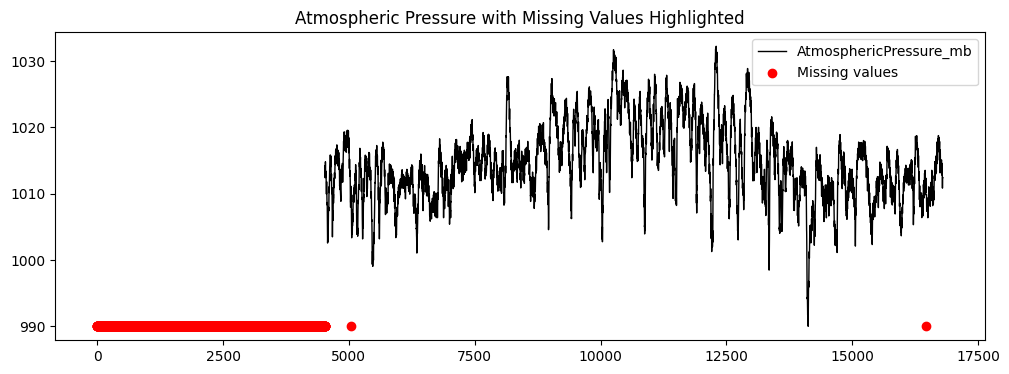

In [236]:
fig, ax = plt.subplots(figsize=(12, 4))

# main line (ignores NaNs automatically)
df["AtmosphericPressure_mb"].plot(ax=ax, color="black", linewidth=1)

# highlight missing points in red
missing = df["AtmosphericPressure_mb"].isna()

ax.scatter(
    df.index[missing],
    [df["AtmosphericPressure_mb"].min()] * missing.sum(),  # place at bottom
    color="red",
    label="Missing values",
    zorder=3
)

ax.set_title("Atmospheric Pressure with Missing Values Highlighted")
ax.legend()
plt.show()

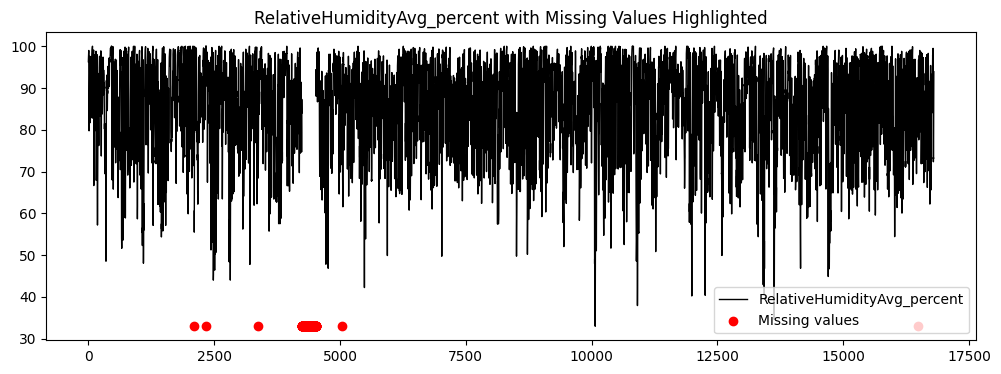

In [237]:
fig, ax = plt.subplots(figsize=(12, 4))

# main line (ignores NaNs automatically)
df["RelativeHumidityAvg_percent"].plot(ax=ax, color="black", linewidth=1)

# highlight missing points in red
missing = df["RelativeHumidityAvg_percent"].isna()

ax.scatter(
    df.index[missing],
    [df["RelativeHumidityAvg_percent"].min()] * missing.sum(),  # place at bottom
    color="red",
    label="Missing values",
    zorder=3
)

ax.set_title("RelativeHumidityAvg_percent with Missing Values Highlighted")
ax.legend()
plt.show()

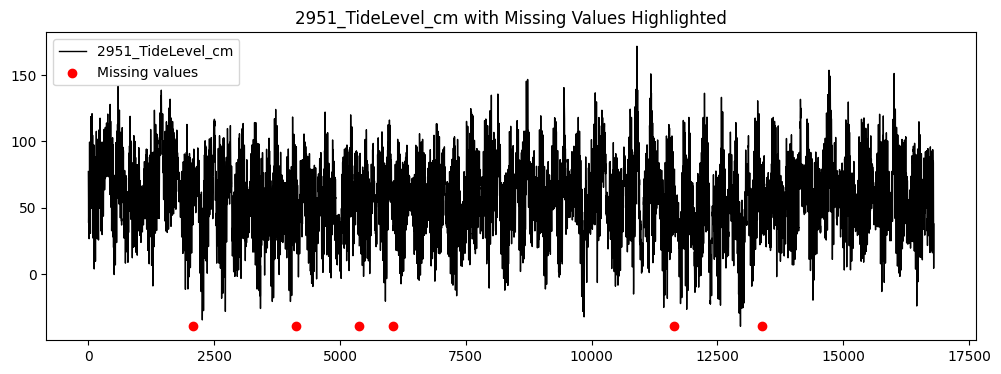

In [241]:
fig, ax = plt.subplots(figsize=(12, 4))

# main line (ignores NaNs automatically)
df["2951_TideLevel_cm"].plot(ax=ax, color="black", linewidth=1)

# highlight missing points in red
missing = df["2951_TideLevel_cm"].isna()

ax.scatter(
    df.index[missing],
    [df["2951_TideLevel_cm"].min()] * missing.sum(),  # place at bottom
    color="red",
    label="Missing values",
    zorder=3
)

ax.set_title("2951_TideLevel_cm with Missing Values Highlighted")
ax.legend()
plt.show()